### Математическая база GradientBoostingClassifier

#### 1. Расчет базового предсказания (Инициализация ансамбля)
Сначала вычисляется доля объектов класса 1 в выборке:
$$p_0 = \frac{\sum_{i=1}^{N} y_i}{N}$$

Затем эта вероятность переводится в пространство сырых логов через функцию Log-Odds (логарифм отношения шансов):
$$F_0(x) = \ln\left(\frac{p_0}{1 - p_0}\right)$$

#### 2. Функция активации (Сигмоида)
Для прямого перевода накопленных логитов $F_m(x)$ в вероятности $p$ применяется логистическая функция. Для защиты от переполнения используется численно стабильная форма:
$$\sigma(x) = \begin{cases} \frac{1}{1 + e^{-x}}, & \text{если } x \ge 0 \\ \frac{e^x}{1 + e^x}, & \text{если } x < 0 \end{cases}$$

#### 3. Функция потерь (Бинарная кросс-энтропия)
Критерий оптимизации (LogLoss). Предсказанные вероятности $\hat{p}$ предварительно зажимаются в диапазон $[\epsilon, 1 - \epsilon]$ (где $\epsilon = 10^{-15}$), чтобы избежать неопределенности логарифма нуля:
$$L(y, \hat{p}) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \ln(\hat{p}_i) + (1 - y_i) \ln(1 - \hat{p}_i) \right]$$

#### 4. Вычисление вектора псевдо-остатков (Антиградиент)
На каждом шаге бустинга $m$ берется антиградиент функции потерь по сырым предсказаниям модели. Для LogLoss частная производная упрощается до разности истинного таргета и текущей вероятности:
$$r_{im} = -\left[ \frac{\partial L(y_i, \sigma(F(x_i)))}{\partial F(x_i)} \right] = y_i - \sigma(F_{m-1}(x_i))$$
*Именно на этот вектор остатков $r_m$ на каждой итерации обучается новое дерево регрессии $h_m(x)$.*

#### 5. Шаг обновления ансамбля
Сырые предсказания модели обновляются путем сложения старых предсказаний и ответов нового дерева, взвешенных на темп обучения $\eta$ (`learning_rate`):
$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

In [32]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

class GradientBoostingClassifier:
    """
    Реализует алгоритм Градиентного Бустинга над решающими деревьями для задач бинарной классификации.
    
    Модель последовательно строит ансамбль из базовых деревьев регрессии (DecisionTreeRegressor), 
    где каждое следующее дерево обучается на антиградиенте (остатках) логистической функции потерь 
    относительно текущих предсказаний всей системы. Модель поддерживает минимизацию функции потерь LogLoss (кросс-энтропия), 
    ведет мониторинг процесса обучения, а также поддерживает критерий ранней остановки для предотвращения избыточного обучения.
    
    Аргументы инициализации:
    ------------------------
    learning_rate : float, default=0.1    
        Скорость обучения (шаг градиентного спуска), контролирующая вклад каждого нового дерева в финальный ансамбль. 
        Помогает предотвратить переобучение.
    n_estimators : int, default=100    
        Количество последовательно настраиваемых деревьев в ансамбле.
    max_depth : int, default=3    
        Максимальная глубина каждого отдельного базового дерева регрессии.
    min_samples_split : int, default=2    
        Минимальное количество объектов в узле дерева, необходимое для совершения очередного сплита (разделения).
    min_samples_leaf : int, default=1    
        Минимальное количество объектов, которое должно находиться в финальном листе дерева.
    random_state : int, None, default=None    
        Генератор случайных чисел для фиксации случайности при построении сплитов в решающих деревьях.
    stop_gr : float, default=1e-4    
        Критерий ранней остановки. Обучение прерывается, если абсолютное изменение функции потерь между
        соседними итерациями бустинга становится меньше или равно этому значению.
        
    Основные методы:
    ----------------
    sigmoid(x)    
        Внутренний метод. Вычисляет логистическую функцию (сигмоиду) для перевода сырых предсказаний
        в вероятности целевого класса. Защищен от переполнения экспоненты при больших значениях x.
    LogLoss(y, pred)    
        Вычисляет функцию потерь бинарной кросс-энтропии между истинными метками и предсказанными вероятностями. 
        Включает в себя ограничение вероятностей для предотвращения деления на ноль и получения неопределенностей (NaN).
    fit(X, y)    
        Запускает последовательный цикл обучения n_estimators деревьев. На каждом шаге рассчитывает вероятности, 
        вычисляет вектор псевдо-остатков (антиградиент функции потерь), обучает на них новое регрессионное дерево, 
        обновляет вектор текущих сырых предсказаний и логирует текущую ошибку в историю.
    predict_proba(X)    
        Рассчитывает вероятности принадлежности к классам для переданной матрицы признаков X. 
        Возвращает двумерную матрицу, где первый столбец — вероятность класса 0, а второй — вероятность класса 1.
    predict(X, threshold=0.5)    
        Рассчитывает финальные дискретные метки классов (0 или 1) на основе предсказанных вероятностей класса 1 и 
        заданного порога отсечения threshold.
        
    Внутренние атрибуты: 
    --------------------
    self.base_pred : float   
        Стартовое базовое предсказание в пространстве логитов (натуральный логарифм отношения шансов классов), 
        вычисленное на этапе инициализации в fit.
    self.trees : list    
        Список, содержащий объекты всех обученных базовых деревьев регрессии (DecisionTreeRegressor).
    self.history_loss : list    
        Список значений функции потерь LogLoss на каждой итерации бустинга для мониторинга сходимости.
    self.epoch : int    
        Фактическое количество итераций (деревьев), которое потребовалось модели до завершения обучения.
    self.feature_importances_ : numpy.ndarray    
    Свойство класса, возвращающее усредненную важность признаков по всему ансамблю обученных деревьев.
    """
    def __init__(self, learning_rate = 0.1, n_estimators = 100, max_depth = 3, min_samples_split = 2, min_samples_leaf = 1, 
                 random_state=None, stop_gr = 1e-4):
        self.learning_rate = learning_rate 
        self.n_estimators = n_estimators 
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split 
        self.min_samples_leaf = min_samples_leaf 
        self.trees = []
        self.base_pred = None
        self.random_state= random_state
        self.history_loss = []
        self.stop_gr = stop_gr
        
    def sigmoid(self, x):
        return np.where(x >= 0, 1/(1+np.exp(-x)), np.exp(x)/(1+np.exp(x)))

    def LogLoss(self, y, pred):
        pred = np.clip(pred, 1e-15, 1 - 1e-15)
        return -np.mean(y * np.log(pred) + (1 - y) * np.log(1 - pred))
        
    def fit(self, X,y):
        p =  np.sum(y) / X.shape[0] 
        self.base_pred = np.log(p / (1-p))
        pred = np.full(shape = X.shape[0], fill_value = self.base_pred)
        
        for estim in range(self.n_estimators):  
            loss = self.LogLoss(y,self.sigmoid(pred))
            
            tree = DecisionTreeRegressor(max_depth = self.max_depth, min_samples_split = self.min_samples_split, 
                                         min_samples_leaf = self.min_samples_leaf, random_state=self.random_state)
            prob = y - self.sigmoid(pred)
            tree.fit(X,prob)

            pred += tree.predict(X) * self.learning_rate

            current_loss = self.LogLoss(y,self.sigmoid(pred))
            
            self.history_loss.append(current_loss)
            self.trees.append(tree)

            self.epoch = estim
            if len(self.history_loss)>1 and abs(self.history_loss[-1] - self.history_loss[-2]) <= self.stop_gr:
                break
                
        return self

    def predict_proba(self,X):
        start_pred = np.full(shape = X.shape[0], fill_value = self.base_pred)
        
        for model in self.trees:
            start_pred += model.predict(X)*self.learning_rate 
            
        return np.column_stack((1-self.sigmoid(start_pred),self.sigmoid(start_pred)))

    def predict(self,X, threshold=0.5):
        return np.where(self.predict_proba(X)[:,1]>=threshold,1,0)

    @property
    def plot_loss(self):
        import pandas as pd
        return pd.DataFrame(self.history_loss).plot()

In [33]:
from sklearn.ensemble import GradientBoostingClassifier as SklearnGB
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss

X, y = make_classification(n_samples=500, n_features=10, n_informative=8, n_redundant=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

custom_model = GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=42).fit(X_train, y_train)

custom_preds = custom_model.predict(X_test)
custom_probs = custom_model.predict_proba(X_test)[:, 1]


sklearn_model = SklearnGB(n_estimators=300, max_depth=3, learning_rate=0.1, 
                          min_samples_split=2, min_samples_leaf=1, random_state=42, n_iter_no_change=None).fit(X_train, y_train)

sklearn_preds = sklearn_model.predict(X_test)
sklearn_probs = sklearn_model.predict_proba(X_test)[:, 1]


print(f"Custom Accuracy:  {accuracy_score(y_test, custom_preds):.4f}")
print(f"Sklearn Accuracy: {accuracy_score(y_test, sklearn_preds):.4f}")
print(f"Custom LogLoss:   {log_loss(y_test, custom_probs):.4f}")
print(f"Sklearn LogLoss:  {log_loss(y_test, sklearn_probs):.4f}")
print(f"Количество обученных деревьев у вас: {len(custom_model.trees)}")

Custom Accuracy:  0.8600
Sklearn Accuracy: 0.8400
Custom LogLoss:   0.3625
Sklearn LogLoss:  0.3669
Количество обученных деревьев у вас: 300


### Визуализация падения ошибки

<Axes: >

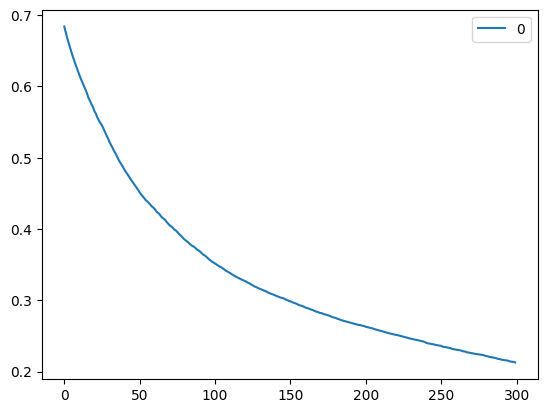

In [34]:
custom_model.plot_loss

In [35]:
sk_featur_impot = sklearn_model.feature_importances_
print(sk_featur_impot)

[0.18231989 0.06443219 0.12309036 0.01641955 0.06563658 0.1995417
 0.16155759 0.02274969 0.02293819 0.14131425]


In [36]:
start = np.zeros(X.shape[1])
for model in custom_model.trees:
    start += model.feature_importances_

cus_featur_impot = start / custom_model.epoch
print(cus_featur_impot)

[0.14993592 0.08709836 0.16037569 0.00817366 0.07730526 0.17540049
 0.15628632 0.02902342 0.02525726 0.1344881 ]


**Из-за пересчета листьев по Ньютону-Рафсону вероятности в sklearn меняются быстрее и точнее. Векторы остатков (y - p) в костомной и в sklearn со временем начинают различаться. В результате на поздних итерациях деревья выбирают разные сплиты, что напрямую меняет финальную сумму важности признаков.**
Главное: Паттерн совпадает!

Структуры деревьев выделили одни и те же ведущие признаки:

У sklearn самый важный признак шестой (индекс 5) — 0.1995, как и в кастомной модели — 0.1754.

У sklearn на втором месте первый признак (индекс 0) — 0.1823, кастомной он тоже очень весом — 0.1499.

Самые бесполезные признаки (индексы 3, 7, 8) обе модели оценили минимально (около 0.01 - 0.02).